## Problem description - Dynamics (FEM pièges)

- In dynamic simulations, certain parameters must be chosen carefully in order to assure the correct propagation of waves.

- In this tutorial we consider a beam embedded on the left and subjected to an initial compressive force on the right. 

- We will look at the impact of the choice of the timestep on the propagation of the wave. 

- The material properties of the beam are the following: 
    - Young's modulu:   $E = 2.11e11$ $Pa$
    - density:          $\rho = 7800$ $kg/m^3$
    - Poisson ratio:    $\nu = 0$

<div>
<img src="Beam.png" width="500"/>
</div>

## Choice of timestep

- The stable time step corresponds to the time the fastest wave (the compressive wave) needs to travel the characteristic length of the mesh:

$$\Delta t_{stable} = \frac{\Delta x}{c}$$


- With :
    - $\Delta x $ : the characteristic length.
    - $c$: the celerity of the fastest wave in the material. It is generally the compressive wave of celerity $c = \sqrt{\frac{2\mu + \lambda}{\rho}}$, where $μ$ and $λ$ are the first and second Lame’s coefficients and $ρ$ is the density. 


- Additionally, it is recommended to impose a time step that is smaller than the stable time step, for instance, by multiplying the stable time step by a safety factor smaller than one.



## Import all necessary modules/functions

In [1]:
import sys
from solid_mechanics import solid_mechanics
from plot_energy import plot_energy

sys.path.insert(1, '../Files')

from create_beam_mesh import create_beam_mesh

## Parameters 

Info    : Running 'gmsh -2 -order 1 -o beam.msh beam.geo' [Gmsh 4.4.1, 1 node, max. 1 thread]
Info    : Started on Wed May  4 09:25:06 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : Meshing curve 1 (Line)
Info    : Meshing curve 2 (Line)
Info    : Meshing curve 3 (Line)
Info    : Meshing curve 4 (Line)
Info    : Done meshing 1D (0.000401309 s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (0.00390922 s)
Info    : 129 vertices 260 elements
Info    : Writing 'beam.msh'...
Info    : Done writing 'beam.msh'
Info    : Stopped on Wed May  4 09:25:06 2022
Mesh generated
The timestep is : 3.2674583596417474e-05
The stable timestep is : 2.63136085494651e-05


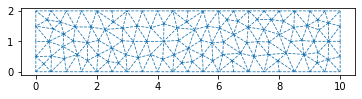

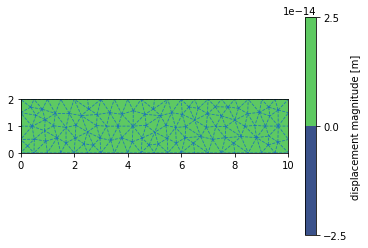

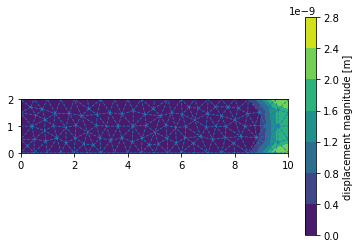

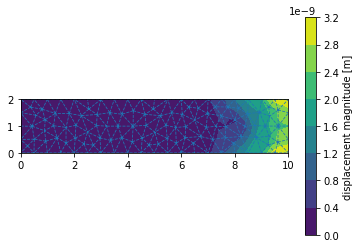

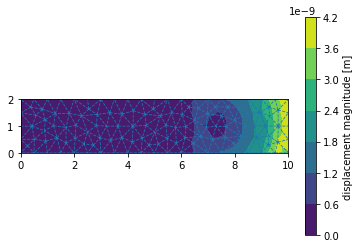

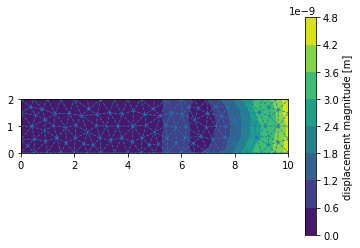

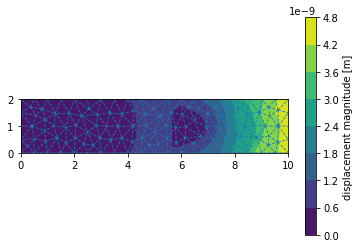

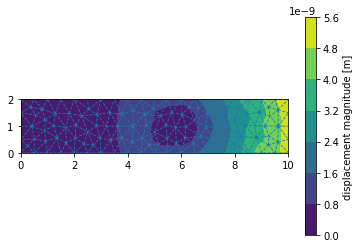

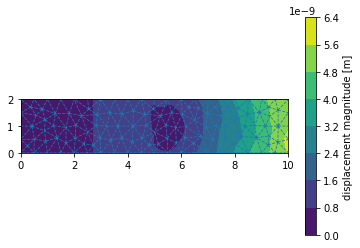

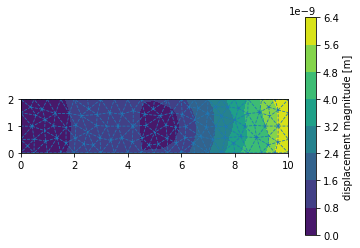

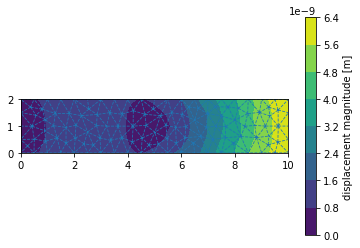

The timestep is : 0.0001
The stable timestep is : 2.63136085494651e-05


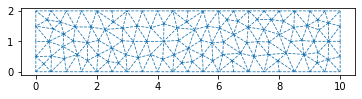

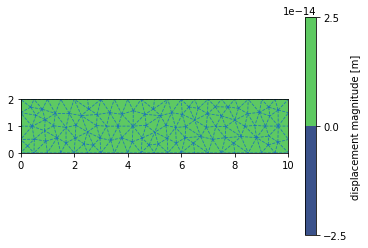

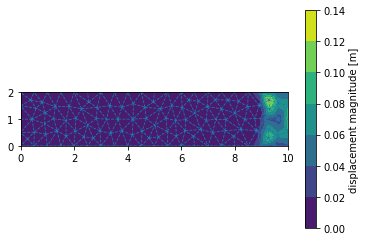

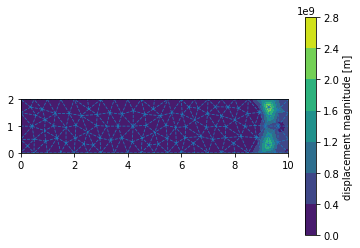

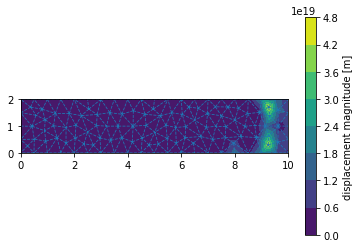

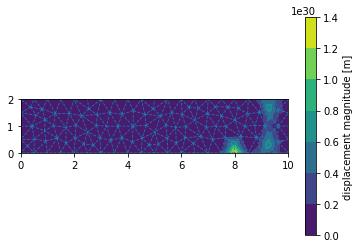

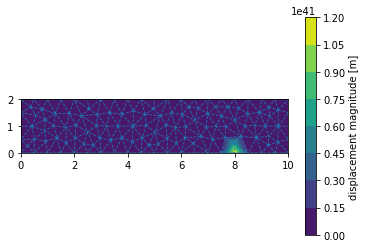

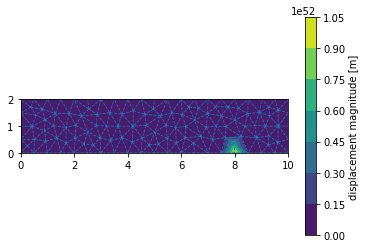

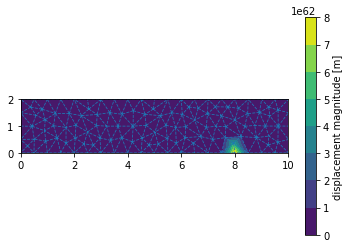

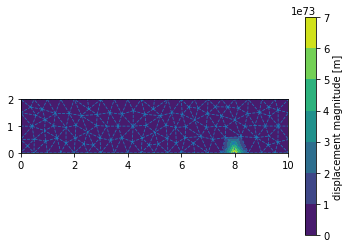

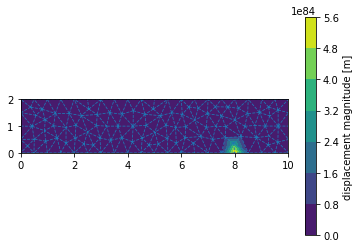

In [2]:
# Create_beam_mesh
L = 10                        # Length of the beam
H = 2                         # Hight of the beam
h = 0.5                       # Mesh element size
create_beam_mesh(L, H, h)

# Set up the system, compute the stable timestep, and show mesh
F = 1000
timestep = 3.2674583596417474e-05
max_steps = 100
dump_every = 10
plot_every = 100
show_plot = "show_plot_yes"   # show the displacement in the beam through time (if not: "show_plot_no")
Energy_kinetic, Energy_potential, Energy_total, time = solid_mechanics(timestep, F, max_steps, dump_every, show_plot)

timestep = 0.0001
show_plot = "show_plot_yes"   # show the displacement in the beam through time (if not: "show_plot_no")
Energy_kinetic2, Energy_potential2, Energy_total2, time2 = solid_mechanics(timestep, F, max_steps, dump_every, show_plot)

## Plot Energy

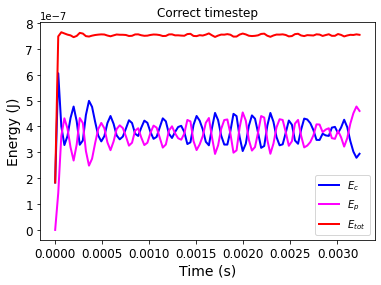

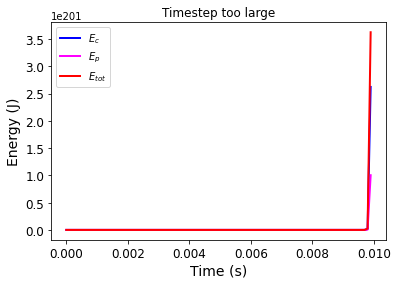

In [3]:
plot_energy(Energy_kinetic, Energy_potential, Energy_total, time, "Correct timestep")
plot_energy(Energy_kinetic2, Energy_potential2, Energy_total2, time2, "Timestep too large")